links a ordenar:
    
    
    https://www.sarem-seitz.com/topics/
        
    https://www.sarem-seitz.com/simple-time-series-models/
        
        
    https://tomaugspurger.github.io/posts/modern-7-timeseries/
        
    https://tomaugspurger.github.io/posts/modern-6-visualization/
        
    https://pages.stern.nyu.edu/~wgreene/Text/econometricanalysis.htm
        
    https://towardsdatascience.com/time-series-in-python-exponential-smoothing-and-arima-processes-2c67f2a52788

# S&P 500

# **1. GENERACION SINTETICA DE PROCESOS ARMA**


In [1]:
import pandas as pd
import numpy as np
np.random.seed(42)
from random import gauss
from pandas.plotting import autocorrelation_plot
import warnings
import itertools
from random import random




import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AR
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
from string import ascii_letters
import seaborn as sns


# general settings
class CFG:
    data_folder = '../data/'
    img_dim1 = 25
    img_dim2 = 8
    style = 'fivethirtyeight'
    
    
# adjust the parameters for displayed figures    
plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})    
plt.style.use(CFG.style) 


In [2]:
# FUNCIONES

# FUNCION PARA API
def sdt_get(serie,**kwargs):
  '''
  kwargs: 
              - start_date/end_date
              - collapse: week / month / quarter / year
              - collapse_aggregation: min / max / avg (default) / end_of_period * sólo se puede usar para consultas individuales
              - representation_mode: value (default) / change / change_a_year_ago / change_since_beginning_of_year / percent_change / percent_change_a_year_ago / percent_change_since_beginning_of_year
  '''
  if isinstance(serie, list):
    serie_ls = serie
    serie = ','.join(serie)
  settings = serie+'&'
  for k,v in kwargs.items():
    settings = settings + f"{k}={v}"+'&'
  print(settings)
  data = f"https://apis.datos.gob.ar/series/api/series/?format=csv&last=5000&ids={settings}"
  output = pd.read_csv(data).set_index('indice_tiempo')
  output.index = pd.to_datetime(output.index)
  return output

def sdt_compare(serie):
    '''
    compara los momentos de la distribución partinedo la serie en 2
    '''
    split =  int(len(serie) / 2)
    X1, X2 = serie[0:split], serie[split:]
    mean1, mean2 = np.round(X1.mean(),0), np.round(X2.mean(),0)
    std1, std2 = np.round(X1.std(),0), np.round(X2.std(),0)
    print(f'media A:{mean1} - media B:{mean2} - ratio A/B = {np.round(100*mean1/mean2,2)}%')
    print(f'desvest A : {std1} - desvest B: {std2}  - ratio A/B = {np.round(100*std1/std2,2)}%')
    return [mean1,mean2,std1,std2]

def sdt_auto_scatter(series,lags=9,ncols=3):
    '''
    gráfico de scatterplot para los rezagos
    '''
    series = pd.Series(series)
    
    nrows=int(np.ceil(lags/ncols))
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols, 4*nrows))
    for ax, lag in zip(axes.flat, np.arange(1,lags+1, 1)):
        lag_str = 't-{}'.format(lag)
        X = (pd.concat([series, series.shift(-lag)], axis=1,
                       keys=['y'] + [lag_str]).dropna())

        X.plot(ax=ax, kind='scatter', y='y', x=lag_str);
        corr = X.corr().to_numpy()[0][1]# X.corr().as_matrix()[0][1] 
        ax.set_ylabel('Original')
        ax.set_title('Lag: {} (corr={:.2f})'.format(lag_str, corr));
        ax.set_aspect('equal');
        sns.despine();
    fig.tight_layout();
    
def sdt_adf(serie):
  '''
  Test de Estacionariedad ADF
  '''
  result = adfuller(serie)
  print('ADF Statistic: %f' % result[0])
  print('p-value: %f' % result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print('\t%s: %.3f' % (key, value))
  return result 


def sdt_sim(AR=[],I=0,MA=[],obs=1000,seed=113,title=''):
    '''
    simulador de procesos arima
    '''
    np.random.seed(seed)
    arparams = np.array(AR)
    maparams = np.array(MA)
    ar = np.r_[1, -arparams] # add zero-lag and negate
    ma = np.r_[1, maparams] # add zero-lag
    arma_process = sm.tsa.ArmaProcess(ar, ma)
    y = arma_process.generate_sample(1000)
    for i in range(I):
        y = y.cumsum()
    tsplot(pd.Series(y),title=title);
    return y

---

In [3]:
BASE_QUANDL_API = 'https://www.quandl.com/api/v3/datasets/'
fred_gdp_call = BASE_QUANDL_API + 'FRED/GDP.csv'
wiki_aapl_call = BASE_QUANDL_API + 'WIKI/AAPL.csv'

In [110]:
test = df_fred_gdp = pd.read_json('https://www.quandl.com/api/v3/datasets/')


ValueError: Expected object or value

In [118]:
# !pip install opendatasets
import opendatasets as od
# od.download("https://www.kaggle.com/rashikrahmanpritom/heart-attack-analysis-prediction-dataset")
od.download("https://www.kaggle.com/datasets/konradb/foreign-exchange-rates-daily-updates")
# username:
# juanivazquez
# api_key:
# 934a657219cbfa4501b9d6a911bc0647


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  juanivazquez


Your Kaggle Key:

  ································


100%|██████████| 2.85M/2.85M [00:00<00:00, 15.9MB/s]

# YFINANCE TUTORIAL

https://analyzingalpha.com/yfinance-python

In [147]:
# pip install yfinance --upgrade --no-cache-dir

In [3]:
def history(self, period="1mo", interval="1d",
            start=None, end=None, prepost=False, actions=True,
            auto_adjust=True, back_adjust=False,
            proxy=None, rounding=False, tz=None, timeout=None, **kwargs):
    """
    :Parameters:
        period : str
            Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
            Either Use period parameter or use start and end
        interval : str
            Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
            Intraday data cannot extend last 60 days
        start: str
            Download start date string (YYYY-MM-DD) or _datetime.
            Default is 1900-01-01
        end: str
            Download end date string (YYYY-MM-DD) or _datetime.
            Default is now
        prepost : bool
            Include Pre and Post market data in results?
            Default is False
        auto_adjust: bool
            Adjust all OHLC automatically? Default is True
        back_adjust: bool
            Back-adjusted data to mimic true historical prices
        proxy: str
            Optional. Proxy server URL scheme. Default is None
        rounding: bool
            Round values to 2 decimal places?
            Optional. Default is False = precision suggested by Yahoo!
        tz: str
            Optional timezone locale for dates.
            (default data is returned as non-localized dates)
        timeout: None or float
            If not None stops waiting for a response after given number of
            seconds. (Can also be a fraction of a second e.g. 0.01)
            Default is None.
        **kwargs: dict
            debug: bool
                Optional. If passed as False, will suppress
                error message printing to console.
    """

In [4]:
import yfinance as yf
goog = yf.Ticker('goog')
data = goog.history()
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-03-29 00:00:00-04:00,102.720001,102.820000,101.029999,101.900002,26148300,0.0,0.0
2023-03-30 00:00:00-04:00,101.440002,101.610001,100.290001,101.320000,25009800,0.0,0.0
2023-03-31 00:00:00-04:00,101.709999,104.190002,101.440002,104.000000,28086500,0.0,0.0
2023-04-03 00:00:00-04:00,102.669998,104.949997,102.379997,104.910004,20719900,0.0,0.0
2023-04-04 00:00:00-04:00,104.839996,106.099998,104.599998,105.120003,20377200,0.0,0.0


In [6]:
data = goog.history(interval='1m', start='2023-04-15', end='2022-04-27')
data.head()

GOOG: Invalid input - start date cannot be after end date. startDate = 1681531200, endDate = 1651032000


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


In [7]:
def download(tickers, start=None, end=None, actions=False, threads=True,
             group_by='column', auto_adjust=False, back_adjust=False,
             progress=True, period="max", show_errors=True, interval="1d", prepost=False,
             proxy=None, rounding=False, timeout=None, **kwargs):
    """Download yahoo tickers
    :Parameters:
        tickers : str, list
            List of tickers to download
        period : str
            Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
            Either Use period parameter or use start and end
        interval : str
            Valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
            Intraday data cannot extend last 60 days
        start: str
            Download start date string (YYYY-MM-DD) or _datetime.
            Default is 1900-01-01
        end: str
            Download end date string (YYYY-MM-DD) or _datetime.
            Default is now
        group_by : str
            Group by 'ticker' or 'column' (default)
        prepost : bool
            Include Pre and Post market data in results?
            Default is False
        auto_adjust: bool
            Adjust all OHLC automatically? Default is False
        actions: bool
            Download dividend + stock splits data. Default is False
        threads: bool / int
            How many threads to use for mass downloading. Default is True
        proxy: str
            Optional. Proxy server URL scheme. Default is None
        rounding: bool
            Optional. Round values to 2 decimal places?
        show_errors: bool
            Optional. Doesn't print errors if True
        timeout: None or float
            If not None stops waiting for a response after given number of
            seconds. (Can also be a fraction of a second e.g. 0.01)
    """

In [8]:
data = yf.download(['GOOG','META'], period='1mo')
data.head()

[*********************100%***********************]  2 of 2 completed


Adj Close                   Close                    High  \
                  GOOG        META        GOOG        META        GOOG   
Date                                                                     
2023-03-29  101.900002  205.350006  101.900002  205.350006  102.820000   
2023-03-30  101.320000  207.839996  101.320000  207.839996  101.610001   
2023-03-31  104.000000  211.940002  104.000000  211.940002  104.190002   
2023-04-03  104.910004  213.070007  104.910004  213.070007  104.949997   
2023-04-04  105.120003  214.720001  105.120003  214.720001  106.099998   

                               Low                    Open              \
                  META        GOOG        META        GOOG        META   
Date                                                                     
2023-03-29  205.720001  101.029999  202.539993  102.720001  203.559998   
2023-03-30  208.089996  100.290001  202.820007  101.440002  203.380005   
2023-03-31  212.169998  101.440002  206.770004  101.709999  207.240005   
2023-04-03  213.490005  102.379997  208.199997  102.669998  208.839996   
2023-04-04  216.240005  104.599998  212.539993  104.839996  213.389999   

              Volume            
                GOOG      META  
Date                            
2023-03-29  26148300  18851100  
2023-03-30  25009800  22608300  
2023-03-31  28086500  25412000  
2023-04-03  20719900  17924600  
2023-04-04  20377200  21026400

In [9]:
data = yf.download(['GOOG','META','^GSPC'], start='1990-01-01', end='2023-04-15', group_by='ticker')
data.head()

[*********************100%***********************]  3 of 3 completed


META                                 GOOG                           \
           Open High Low Close Adj Close Volume Open High Low Close Adj Close   
Date                                                                            
1990-01-02  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN       NaN   
1990-01-03  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN       NaN   
1990-01-04  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN       NaN   
1990-01-05  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN       NaN   
1990-01-08  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN       NaN   

                        ^GSPC                                                  \
           Volume        Open        High         Low       Close   Adj Close   
Date                                                                            
1990-01-02    NaN  353.399994  359.690002  351.980011  359.690002  359.690002   
1990-01-03    NaN  359.690002  360.589996  357.890015  358.760010  358.760010   
1990-01-04    NaN  358.760010  358.760010  352.890015  355.670013  355.670013   
1990-01-05    NaN  355.670013  355.670013  351.350006  352.200012  352.200012   
1990-01-08    NaN  352.200012  354.239990  350.540009  353.790009  353.790009   

                       
               Volume  
Date                   
1990-01-02  162070000  
1990-01-03  192330000  
1990-01-04  177000000  
1990-01-05  158530000  
1990-01-08  140110000

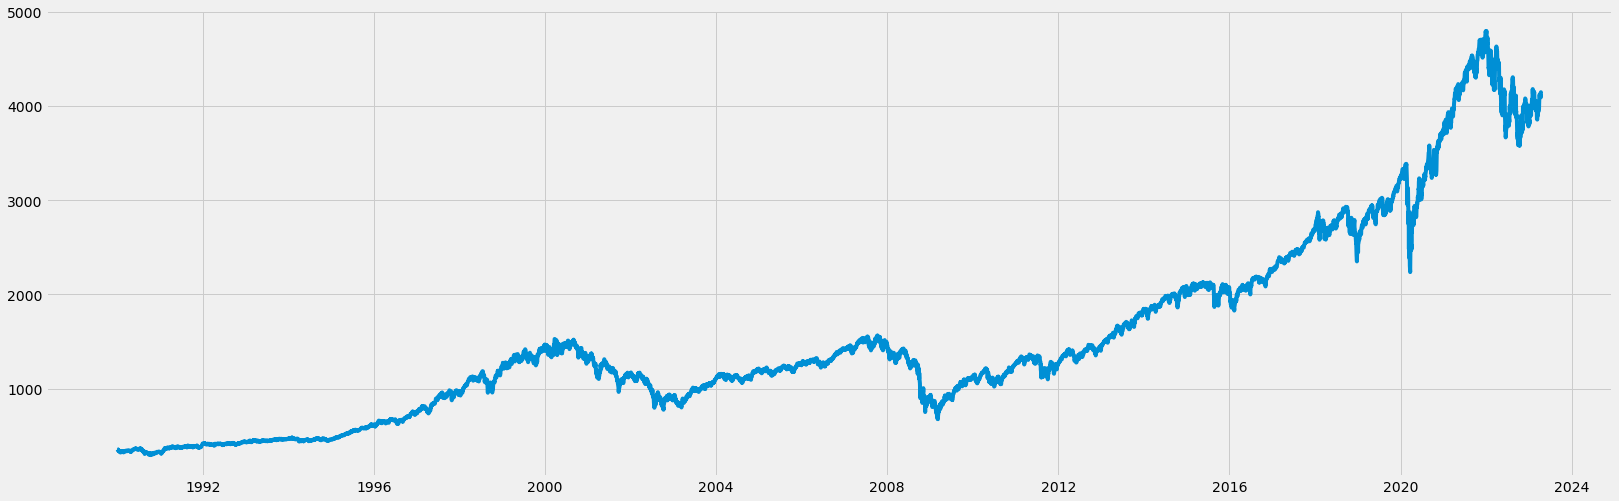

In [146]:
plt.plot(data[[('^GSPC',     'Close')]])

# KAGGLE FOREX

In [123]:
df_fx = pd.read_csv(r'C:\Users\juani\Documents\3_My_Jupiter_Notebooks\4_Series_de_Tiempo\0_AULA\foreign-exchange-rates-daily-updates\fx_data.csv')
len(df_fx.columns)

121

In [148]:
df_fred_gdp = pd.read_csv(fred_gdp_call)
# df_fred_gdp

# FRED

In [ ]:
import requests

In [5]:
BASE_FRED_API = 'https://api.stlouisfed.org/fred/'
FRED_SERIES_METADATA = BASE_FRED_API + 'series?series_id={serie_id}&api_key={api_key}&file_type=json'
FRED_SERIES_DATA = BASE_FRED_API + 'series/observations?series_id={serie_id}&api_key={api_key}&file_type=json'
fred_key = '1bec1d5e61bea53dc72e12053af32db3'

In [88]:
def ajustar(x):
    try:
        return float(x)
    except:
        return np.nan
    
def get_fred_meta(serie_id,fred_key='1bec1d5e61bea53dc72e12053af32db3'):
    meta_call = FRED_SERIES_METADATA.format(serie_id=serie_id, api_key=fred_key)
    temp = requests.get(meta_call).json()
    return temp

def get_fred_data(serie_id,fred_key='1bec1d5e61bea53dc72e12053af32db3'):
    meta_call = FRED_SERIES_METADATA.format(serie_id=serie_id, api_key=fred_key)
    temp = requests.get(meta_call).json()
    
    data_call = FRED_SERIES_DATA.format( serie_id=serie_id, api_key=fred_key )
    temp = requests.get(data_call).json()
    df = pd.DataFrame(temp['observations'])
    df.date = pd.to_datetime(df.date)
    df.set_index('date',inplace=True)
    df.value = df['value'].apply(ajustar)
    df = df[['value']]
    return df


In [ ]:
snp = 'SP500'
egg = 'APU0200708111'


In [98]:
df_snp = get_fred_data('SP500')
df_egg = get_fred_data('APU0200708111')

In [108]:
df_egg[df_egg.index.year>2012].div(df_egg[df_egg.index.year>2012].value[0]/100)

,value
date,
2013-01-01,100.000000
2013-02-01,101.401869
2013-03-01,95.093458
2013-04-01,96.787383
2013-05-01,87.792056
...,...
2022-11-01,197.838785
2022-12-01,240.128505
2023-01-01,259.404206


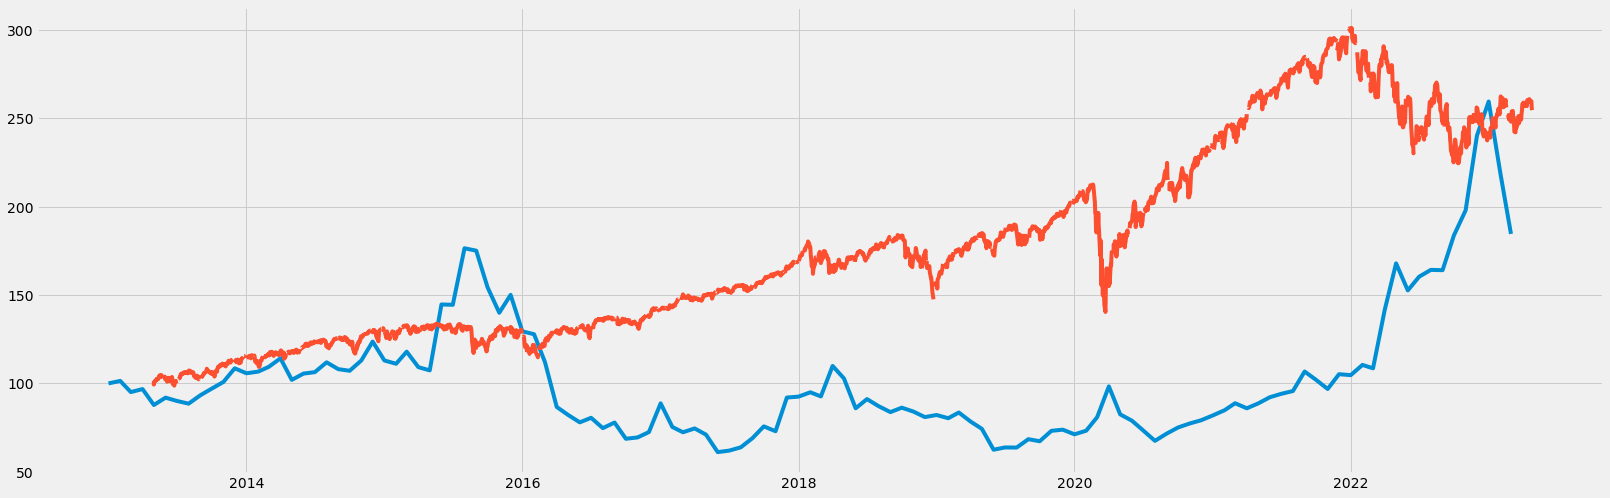

In [109]:
plt.plot(df_egg[df_egg.index.year>2012].div(df_egg[df_egg.index.year>2012].value[0]/100))
plt.plot(df_snp[df_snp.index.year>2012].div(df_snp[df_snp.index.year>2012].value[0]/100))

In [12]:
# METADATA
gdp_meta_call = FRED_SERIES_METADATA.format(
    serie_id='GNPCA', api_key=fred_key
)

gdp_metadata = requests.get(gdp_meta_call).json()
gdp_metadata

{'realtime_start': '2023-04-27',
 'realtime_end': '2023-04-27',
 'seriess': [{'id': 'GNPCA',
   'realtime_start': '2023-04-27',
   'realtime_end': '2023-04-27',
   'title': 'Real Gross National Product',
   'observation_start': '1929-01-01',
   'observation_end': '2022-01-01',
   'frequency': 'Annual',
   'frequency_short': 'A',
   'units': 'Billions of Chained 2012 Dollars',
   'units_short': 'Bil. of Chn. 2012 $',
   'seasonal_adjustment': 'Not Seasonally Adjusted',
   'seasonal_adjustment_short': 'NSA',
   'last_updated': '2023-03-30 07:54:21-05',
   'popularity': 9,
   'notes': 'BEA Account Code: A001RX\n\n'}]}

In [13]:
# DATA
gdp_data_call = FRED_SERIES_DATA.format(
    serie_id='GNPCA', api_key=fred_key
)
gdp_data = requests.get(gdp_data_call).json()

df_gdp = pd.DataFrame(gdp_data['observations'])
df_gdp

,realtime_start,realtime_end,date,value
0,2023-04-27,2023-04-27,1929-01-01,1120.718
1,2023-04-27,2023-04-27,1930-01-01,1025.678
2,2023-04-27,2023-04-27,1931-01-01,958.927
3,2023-04-27,2023-04-27,1932-01-01,834.769
4,2023-04-27,2023-04-27,1933-01-01,823.628
...,...,...,...,...
89,2023-04-27,2023-04-27,2018-01-01,18874.78
90,2023-04-27,2023-04-27,2019-01-01,19286.841
91,2023-04-27,2023-04-27,2020-01-01,18685.401
92,2023-04-27,2023-04-27,2021-01-01,19759.327


---

# Fred FarmBusiness

https://fred.stlouisfed.org/series/BOGZ1FL135010005Q

In [40]:
data

{'error_code': 400,
 'error_message': 'Bad Request.  Invalid value for variable series_id.  Series IDs should be 25 or less alphanumeric characters.'}

In [45]:
# METADATA
meta_call = FRED_SERIES_METADATA.format(
    serie_id='BOGZ1FL135010005Q', api_key=fred_key
)

metadata = requests.get(meta_call).json()
metadata

{'realtime_start': '2023-04-27',
 'realtime_end': '2023-04-27',
 'seriess': [{'id': 'BOGZ1FL135010005Q',
   'realtime_start': '2023-04-27',
   'realtime_end': '2023-04-27',
   'title': 'Farm Business (Included in Nonfinancial Corporate and Noncorporate Business Sectors); Land at Market Value, Level',
   'observation_start': '1945-10-01',
   'observation_end': '2022-10-01',
   'frequency': 'Quarterly',
   'frequency_short': 'Q',
   'units': 'Millions of Dollars',
   'units_short': 'Mil. of $',
   'seasonal_adjustment': 'Not Seasonally Adjusted',
   'seasonal_adjustment_short': 'NSA',
   'last_updated': '2023-03-15 09:12:06-05',
   'popularity': 2,
   'notes': 'Source ID: FL135010005.Q\n\nFor more information about the Flow of Funds tables, see the Financial Accounts Guide (https://www.federalreserve.gov/apps/fof/Default.aspx).\n\nWith each quarterly release, the source may make major data and structural revisions to the series and tables. These changes are available in the Release Highl

In [64]:
def ajustar(x):
    try:
        return float(x)
    except:
        return np.nan

In [74]:
# DATA
call = FRED_SERIES_DATA.format(
    serie_id='BOGZ1FL135010005Q', api_key=fred_key
)
data = requests.get(call).json()

df = pd.DataFrame(data['observations'])
df.date = pd.to_datetime(df.date)
df.set_index('date',inplace=True)
df.value = df['value'].apply(ajustar)
df = df[['value']]

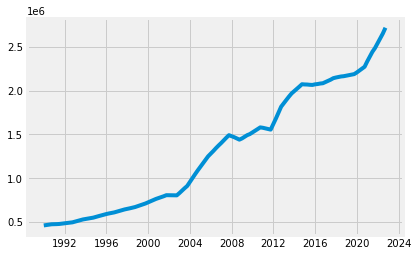

In [76]:
plt.plot(df[(df.index.year>1989)]['value'])

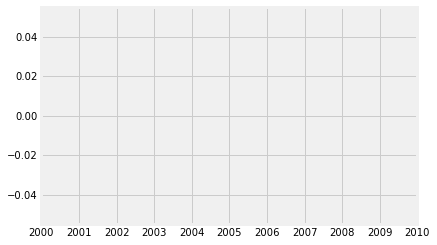

In [49]:
plt.plot(df[(df.index.year>2020)&(df.index.year<2021)].value)

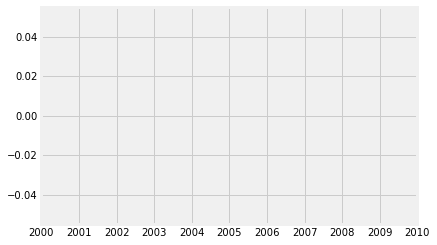

In [48]:
# plt.plot(df[(df.index.year>2020)&(df.index.year<2021)].value)

---

In [309]:
model = sm.tsa.SARIMAX(_, order=(0, 0, 2))

In [314]:
results.bic

7935.668123206626

In [311]:
results = model.fit()
results.__dict__

{'_results': <statsmodels.tsa.statespace.sarimax.SARIMAXResults at 0x1c0a8168c88>,
 '__doc__': '\n    Class to hold results from fitting an SARIMAX model.\n\n    Parameters\n    ----------\n    model : SARIMAX instance\n        The fitted model instance\n\n    Attributes\n    ----------\n    specification : dictionary\n        Dictionary including all attributes from the SARIMAX model instance.\n    polynomial_ar : ndarray\n        Array containing autoregressive lag polynomial coefficients,\n        ordered from lowest degree to highest. Initialized with ones, unless\n        a coefficient is constrained to be zero (in which case it is zero).\n    polynomial_ma : ndarray\n        Array containing moving average lag polynomial coefficients,\n        ordered from lowest degree to highest. Initialized with ones, unless\n        a coefficient is constrained to be zero (in which case it is zero).\n    polynomial_seasonal_ar : ndarray\n        Array containing seasonal autoregressive lag po

In [1]:
import itertools


d_min = 0
q_min = 0
p_max = 4
d_max = 2
q_max = 4


def sdt_explore(series, p = [0,4],d=[0,2],q=[0,4]):
    # Initialize a DataFrame to store the results
    results_bic = pd.DataFrame(index=['AR{}'.format(i) for i in range(p[0],p[1]+1)],
                               columns=['MA{}'.format(i) for i in range(q[0],q[1]+1)])

    for i,j,k in itertools.product(range(p[0],p[1]+1),
                                   range(d[0],d[1]+1),
                                   range(q[0],q[1]+1)):
        if i==0 and j==0 and k==0:
            results_bic.loc['AR{}'.format(i), 'MA{}'.format(k)] = np.nan
            continue

        try:
            model = sm.tsa.SARIMAX(series, order=(i, j, k),
                                   #enforce_stationarity=False,
                                   #enforce_invertibility=False,
                                  )
            results = model.fit()
            results_bic.loc['AR{}'.format(i), 'MA{}'.format(k)] = results.bic
        except:
            continue
    results_bic = results_bic[results_bic.columns].astype(float)
    return results_bic

In [317]:
def sdt_explore(series, p = [0,4],d=[0,2],q=[0,4]):
    # Initialize a DataFrame to store the results
    results_bic = pd.DataFrame(index=['AR{}'.format(i) for i in range(p[0],p[1]+1)],
                               columns=['MA{}'.format(i) for i in range(q[0],q[1]+1)])
    results_aic = results_bic.copy()
    
    for i,j,k in itertools.product(range(p[0],p[1]+1),
                                   range(d[0],d[1]+1),
                                   range(q[0],q[1]+1)):
        if i==0 and j==0 and k==0:
            results_bic.loc['AR{}'.format(i), 'MA{}'.format(k)] = np.nan
            results_aic.loc['AR{}'.format(i), 'MA{}'.format(k)] = np.nan
            continue

        try:
            model = sm.tsa.SARIMAX(series, order=(i, j, k),
                                   #enforce_stationarity=False,
                                   #enforce_invertibility=False,
                                  )
            results = model.fit()
            results_bic.loc['AR{}'.format(i), 'MA{}'.format(k)] = results.bic
            results_aic.loc['AR{}'.format(i), 'MA{}'.format(k)] = results.aic
        except:
            continue
    results_bic = results_bic[results_bic.columns].astype(float)
    results_aic = results_aic[results_aic.columns].astype(float)
    return results_bic, results_aic

In [318]:
bic,aic = sdt_explore(_)

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site

In [324]:
def get_min(df):
    return df.idxmin().loc[df.min().idxmin()], df.min().idxmin() 

In [331]:
aic.div(aic.mean().mean()).round(4)

,MA0,MA1,MA2,MA3,MA4
AR0,1.1618,0.9824,0.9804,0.9803,0.9805
AR1,1.0880,0.9807,0.9833,0.9810,0.9811
AR2,1.0555,0.9805,0.9812,0.9786,0.9809
AR3,1.0415,0.9809,0.9813,0.9811,0.9807
AR4,1.0325,0.9807,0.9815,0.9816,0.9819


In [323]:
aic

,MA0,MA1,MA2,MA3,MA4
AR0,5026.547369,4250.521997,4241.956414,4241.306343,4242.408648
AR1,4707.507958,4243.018860,4254.430992,4244.329202,4244.698244
AR2,4566.543697,4242.182762,4245.354333,4233.890163,4243.892850
AR3,4506.225849,4243.732570,4245.606398,4244.599657,4243.078916
AR4,4467.357569,4243.078355,4246.694416,4247.019317,4248.473893


In [322]:
get_min(aic),get_min(bic)

(('AR2', 'MA3'), ('AR0', 'MA2'))

In [280]:
test = sdt_explore(_)

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\base\model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)
C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site

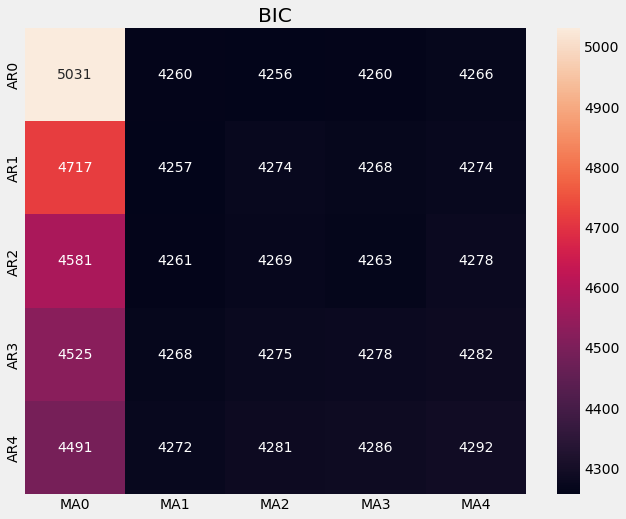

In [287]:
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(test.astype(int),
                 mask=test.isnull(),
                 ax=ax,
                 annot=True,
                 fmt='.0f',
                 );
ax.set_title('BIC');

In [301]:
test.astype(int)

,MA0,MA1,MA2,MA3,MA4
AR0,5031,4260,4256,4260,4266
AR1,4717,4257,4274,4268,4274
AR2,4581,4261,4269,4263,4278
AR3,4525,4268,4275,4278,4282
AR4,4491,4272,4281,4286,4292


In [306]:
best_fit = test.idxmin().loc[test.min().idxmin()], test.min().idxmin() 

('AR0', 'MA2')

# Descomposición

## Estimador Mensual de la Actividad Económica

In [6]:
df = sdt_get(['143.3_NO_PR_2004_A_31','143.3_NO_PR_2004_A_28','143.3_NO_PR_2004_A_21'])
df.head(2)
df.plot();

143.3_NO_PR_2004_A_31,143.3_NO_PR_2004_A_28,143.3_NO_PR_2004_A_21&


,emae_desestacionalizada,emae_tendencia_ciclo,emae_original
indice_tiempo,,,
2004-01-01,98.379403,96.033489,92.627506
2004-02-01,98.013105,96.644992,90.186179


## Estudio por Sectores


In [12]:
df = sdt_get('143.3_NO_PR_2004_A_21,11.3_VMATC_2004_M_12,11.3_VMASD_2004_M_23,11.3_VIPAA_2004_M_5,11.3_ISOM_2004_M_39,11.3_P_2004_M_20,11.3_AGCS_2004_M_41') #678arlyc

df.head(2)

143.3_NO_PR_2004_A_21,11.3_VMATC_2004_M_12,11.3_VMASD_2004_M_23,11.3_VIPAA_2004_M_5,11.3_ISOM_2004_M_39,11.3_P_2004_M_20,11.3_AGCS_2004_M_41&


,emae_original,construccion,industria_manufacturera,pesca,agricultura_ganaderia_caza_silvicultura,hoteles_restaurantes,comercio_mayorista_minorista_reparaciones
indice_tiempo,,,,,,,
2004-01-01,92.627506,95.938047,91.454610,42.547868,65.995350,108.411682,92.065338
2004-02-01,90.186179,98.853388,89.424852,62.440771,64.926598,103.448256,91.464718


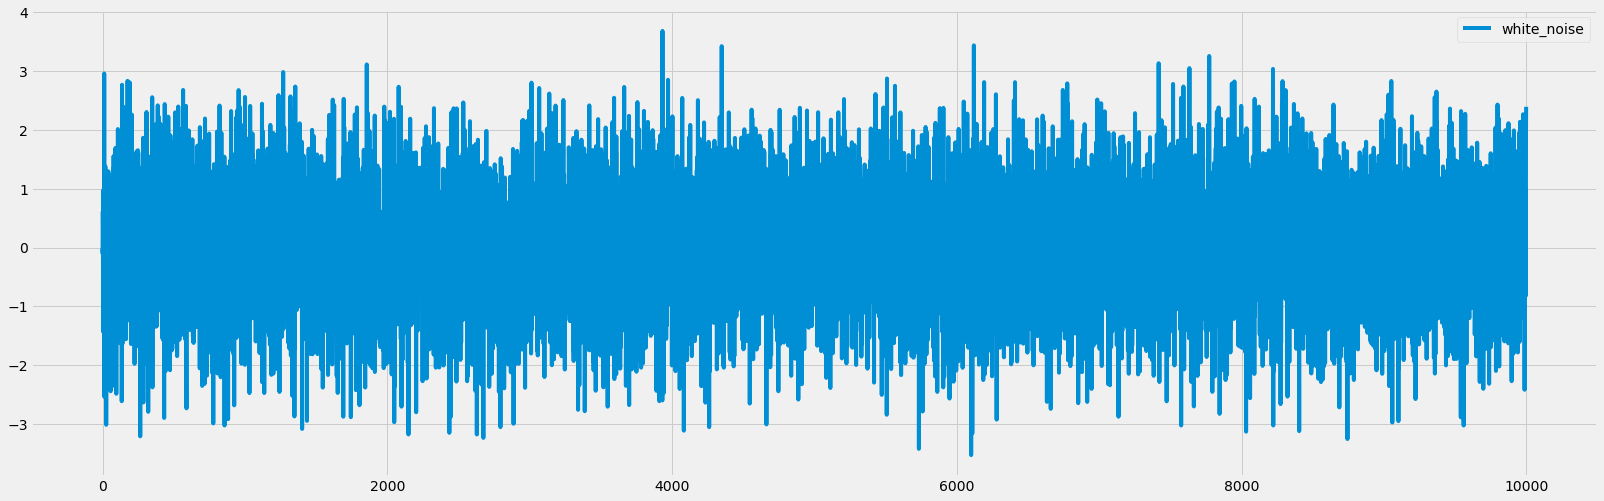

In [238]:
xseries = pd.DataFrame(data = np.random.normal(0, 1, 10000), columns = ['white_noise'] )
xseries.plot()
print()

### SUBE

678arlyc&collapse=week&start_date=2020-05&


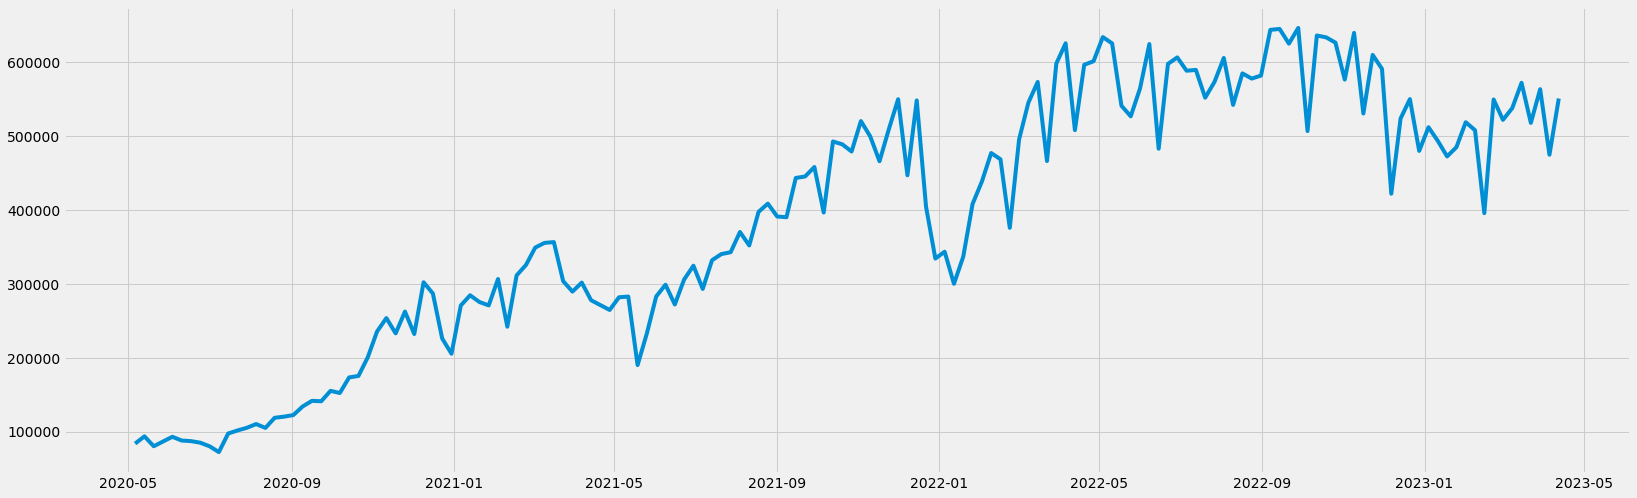

In [23]:
df = sdt_get('678arlyc',collapse='week',start_date='2020-05') 
plt.plot(df)

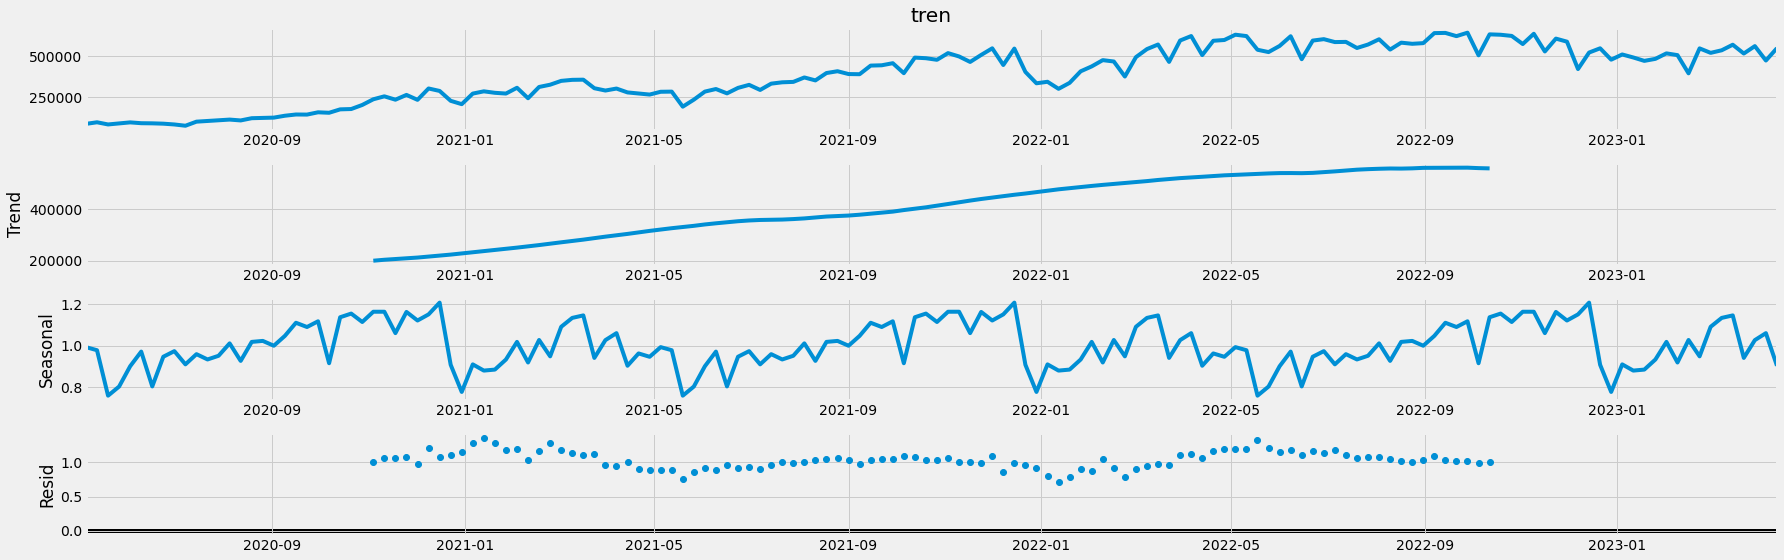

In [25]:
decomposition = sm.tsa.seasonal_decompose(df["tren"],period =52, model = 'multiplicative' ) 
figure = decomposition.plot()
plt.show()

Obtenemos los primeros momentos de la distribución:

In [29]:
X = df.tren.values
split =  int(len(X) / 2)
X1, X2 = X[0:split], X[split:]
mean1, mean2 = np.round(X1.mean()/1000,0), np.round(X2.mean()/1000,0)
var1, var2 = np.round(X1.std()/1000,0), np.round(X2.std()/1000,0)
print('mean:')
print('chunk1: %.2f vs chunk2: %.2f' % (mean1, mean2))
print('variance:')
print('chunk1: %.2f vs chunk2: %.2f' % (var1, var2))


mean:
chunk1: 248.00 vs chunk2: 530.00
variance:
chunk1: 112.00 vs chunk2: 80.00


In [255]:
sdt_compare(_)

media A:0.0 - media B:0.0 - ratio A/B = nan%
desvest A : 2.0 - desvest B: 2.0  - ratio A/B = 100.0%


C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in double_scalars
  


[0.0, 0.0, 2.0, 2.0]

In [39]:
_ = sdt_compare(df.tren.values)

media A:247973.0 - media B:530385.0 - ratio A/B = 46.75%
desvest A : 112411.0 - desvest B: 80339.0  - ratio A/B = 139.92%


## ADF: Test de Estacionariedad

In [46]:
result = sdt_adf(X)

ADF Statistic: -1.639875
p-value: 0.462326
Critical Values:
	1%: -3.474
	5%: -2.881
	10%: -2.577


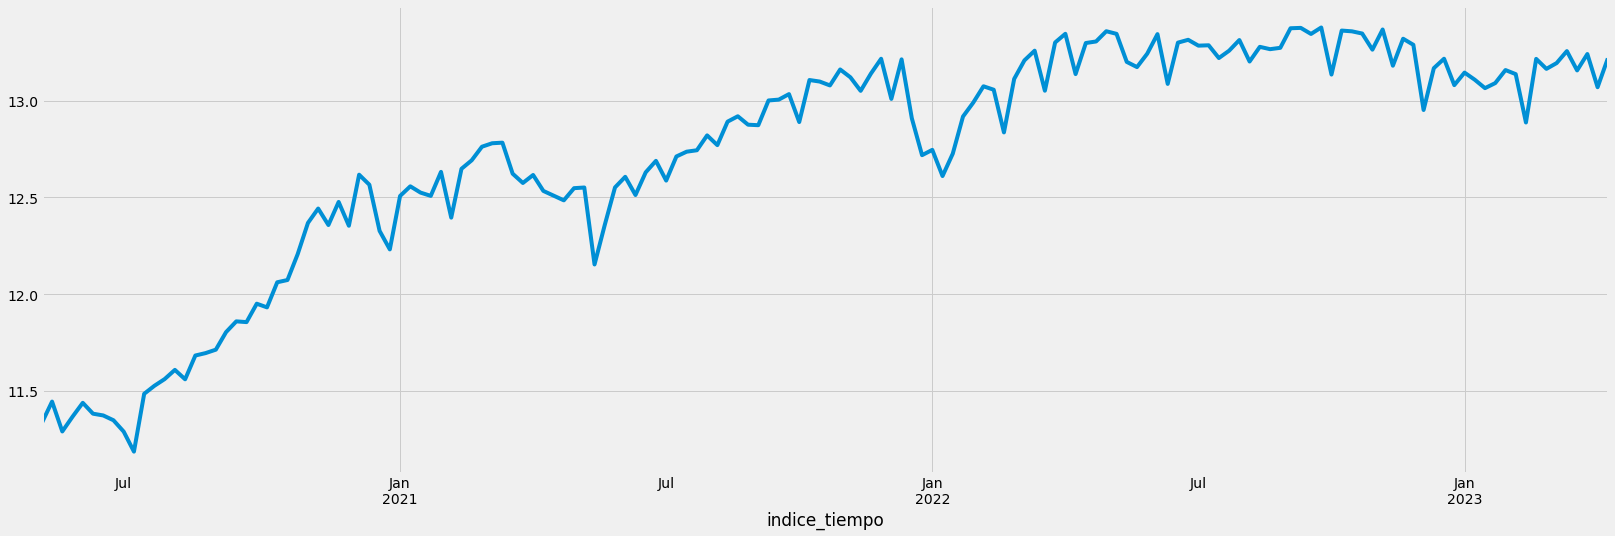

In [50]:
df['tren2'] = np.log(df['tren'])
df.tren2.plot()
plt.show()

La transformación logarítmica nos acerca al rechazo

In [51]:
result = sdt_adf(df.tren2)

ADF Statistic: -2.560683
p-value: 0.101398
Critical Values:
	1%: -3.474
	5%: -2.881
	10%: -2.577


Si a la transformación logarítmica le aplicamos una diferencia:

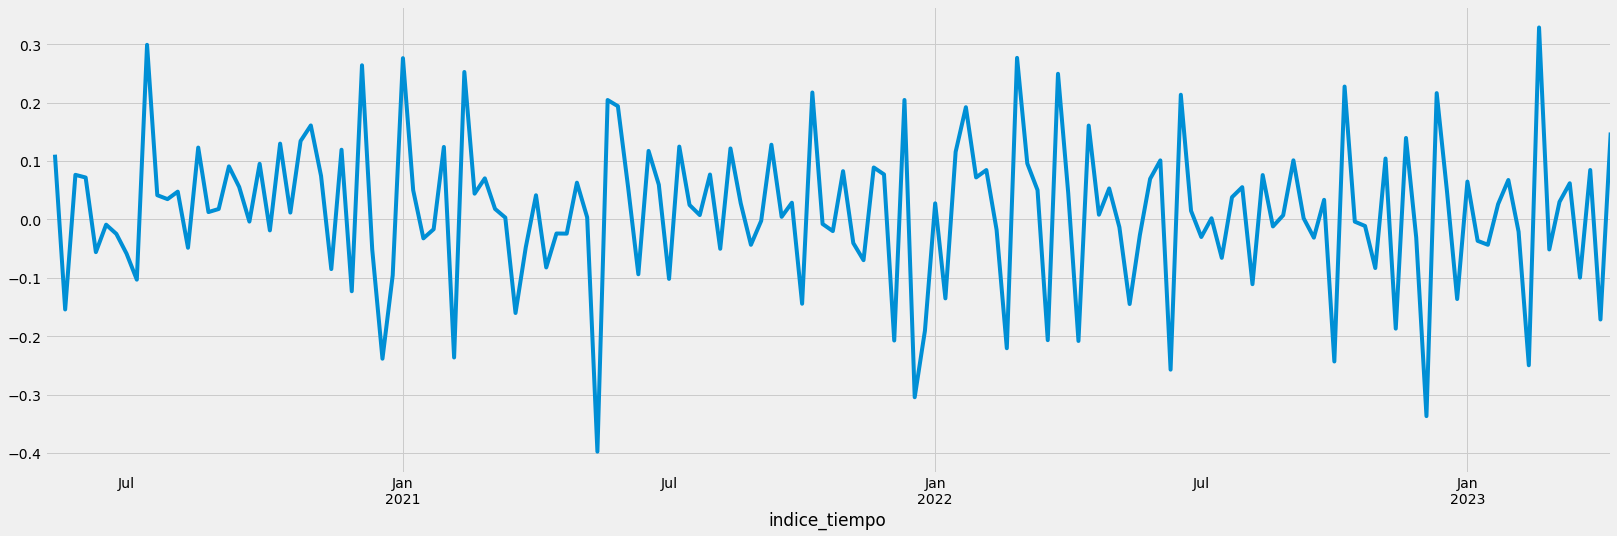

In [52]:
df['diff_tren2'] = df['tren2'].diff()
df.diff_tren2.plot()
plt.show()

Así, obtenemos un rechazo claro:

In [53]:
result = sdt_adf(df.diff_tren2[1:])

ADF Statistic: -12.684296
p-value: 0.000000
Critical Values:
	1%: -3.474
	5%: -2.881
	10%: -2.577


Integrando las transformaciones en una línea de código:

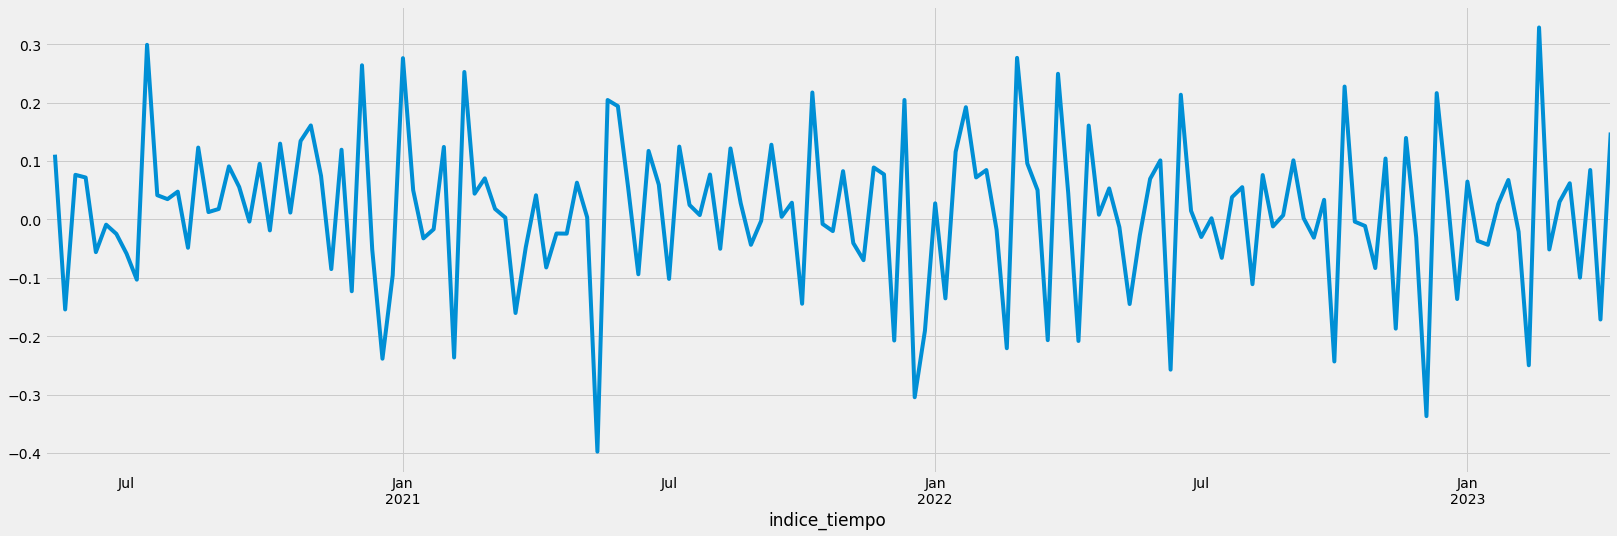

ADF Statistic: -12.684296
p-value: 0.000000
Critical Values:
	1%: -3.474
	5%: -2.881
	10%: -2.577


In [54]:
df['tren_'] = df['tren'].apply(np.log).diff()
df.tren_.plot()
plt.show()
result = sdt_adf(df.tren_[1:])

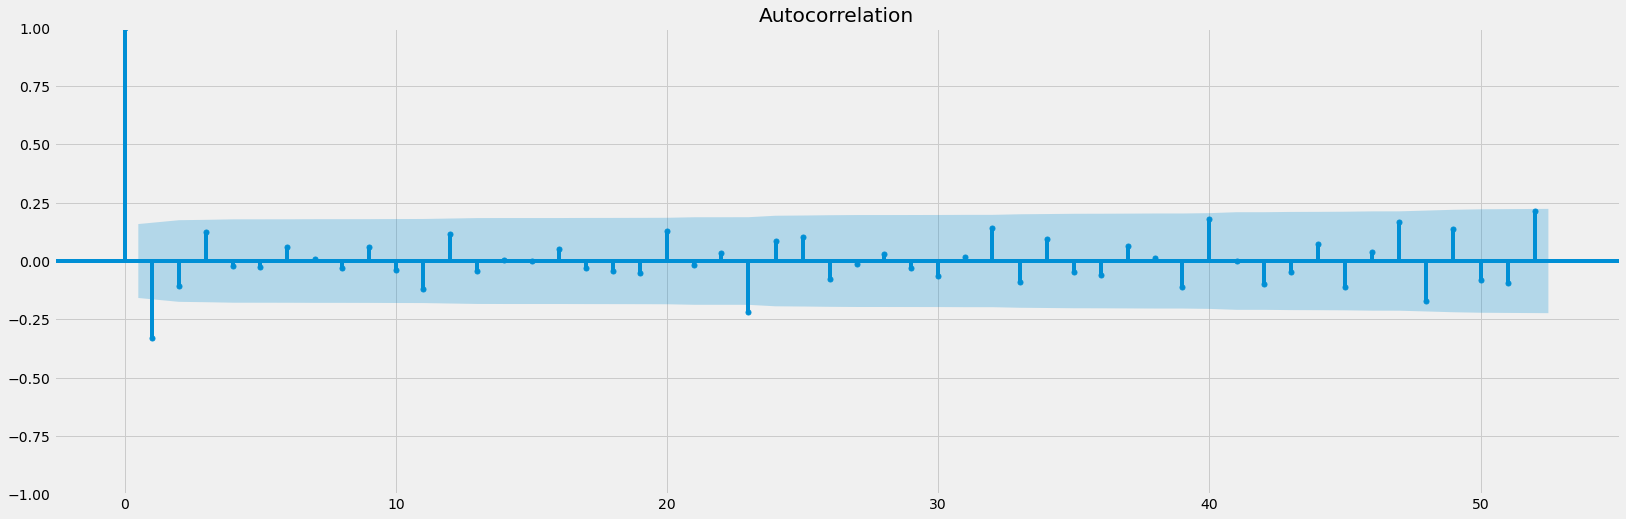

In [55]:
plot_acf(df['tren_'][1:], lags = 52)
plt.show()

In [70]:
def tsplot(y, lags=None, title='', figsize=(14, 7)):
    '''Examine the patterns of ACF and PACF, along with the time series plot and histogram.
    
    Original source: https://tomaugspurger.github.io/modern-7-timeseries.html
    '''
    fig = plt.figure(figsize=figsize)
    layout = (2, 2)
    ts_ax   = plt.subplot2grid(layout, (0, 0))
    hist_ax = plt.subplot2grid(layout, (0, 1))
    acf_ax  = plt.subplot2grid(layout, (1, 0))
    pacf_ax = plt.subplot2grid(layout, (1, 1))
    
    y.plot(ax=ts_ax)
    ts_ax.set_title(title)
    y.plot(ax=hist_ax, kind='hist', bins=25)
    hist_ax.set_title('Histogram')
    smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
    smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
    [ax.set_xlim(0) for ax in [acf_ax, pacf_ax]]
    sns.despine()
    plt.tight_layout()
    return ts_ax, acf_ax, pacf_ax

(<AxesSubplot:xlabel='indice_tiempo'>,
 <AxesSubplot:title={'center':'Autocorrelation'}>,
 <AxesSubplot:title={'center':'Partial Autocorrelation'}>)

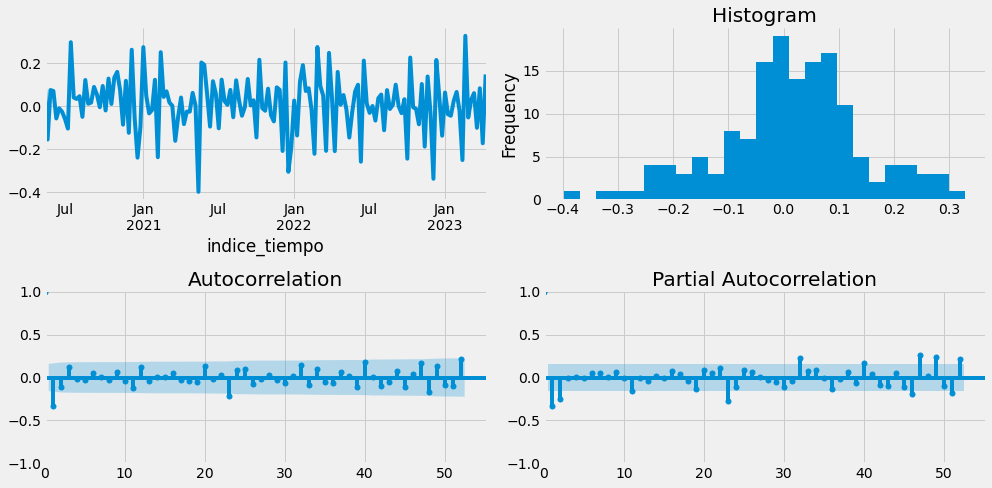

In [71]:
tsplot(df["tren_"][1:],lags=52)

https://www.statsmodels.org/dev/generated/statsmodels.tsa.arima_process.ArmaProcess.html

In [ ]:
# creamos un generador de modelos arima y los exploramos:
1. observamos su comportamiento conjunto y 

In [ ]:
import statsmodels.api as sm
import numpy as np
np.random.seed(42)
arparams = np.array([.75, -.25])
maparams = np.array([.65, .35])
ar = np.r_[1, -arparams] # add zero-lag and negate
ma = np.r_[1, maparams] # add zero-lag
arma_process = sm.tsa.ArmaProcess(ar, ma)
arma_process.isstationary

arma_process.isinvertible

arma_process.arroots
array([1.5-1.32287566j, 1.5+1.32287566j])
y = arma_process.generate_sample(250)
model = sm.tsa.ARIMA(y, (2, 0, 2), trend='n').fit(disp=0)
model.params
array([ 0.79044189, -0.23140636,  0.70072904,  0.40608028])

### White Noise

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


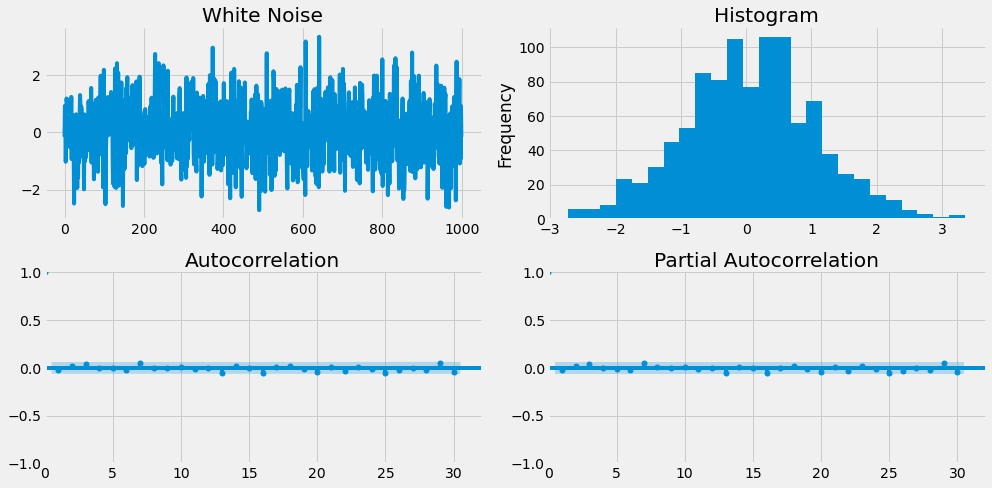

In [190]:
_ = sdt_sim(title='White Noise')

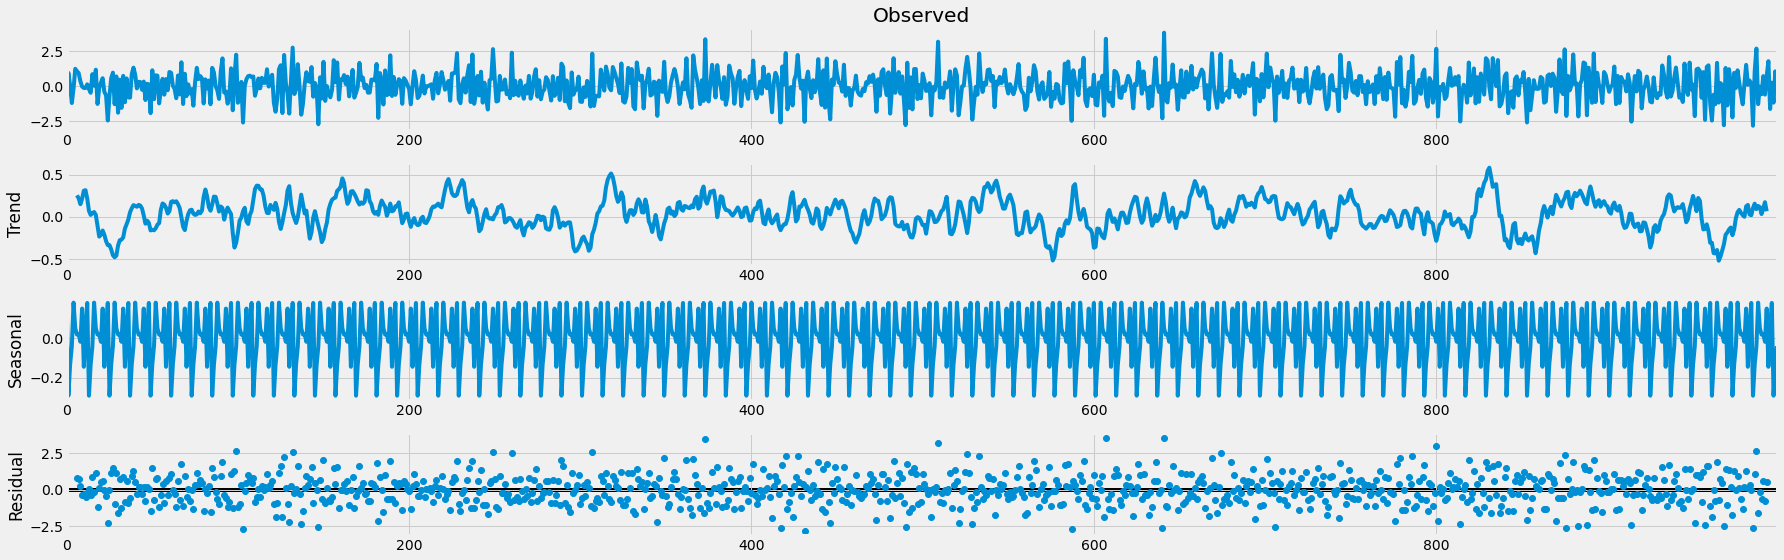

In [228]:
# Descomposición de Ruido Blanco.... qué significa esto?
decomposition = sm.tsa.seasonal_decompose(_,period =12, model = 'additive') 
figure = decomposition.plot()
plt.show()

### Random Walk

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


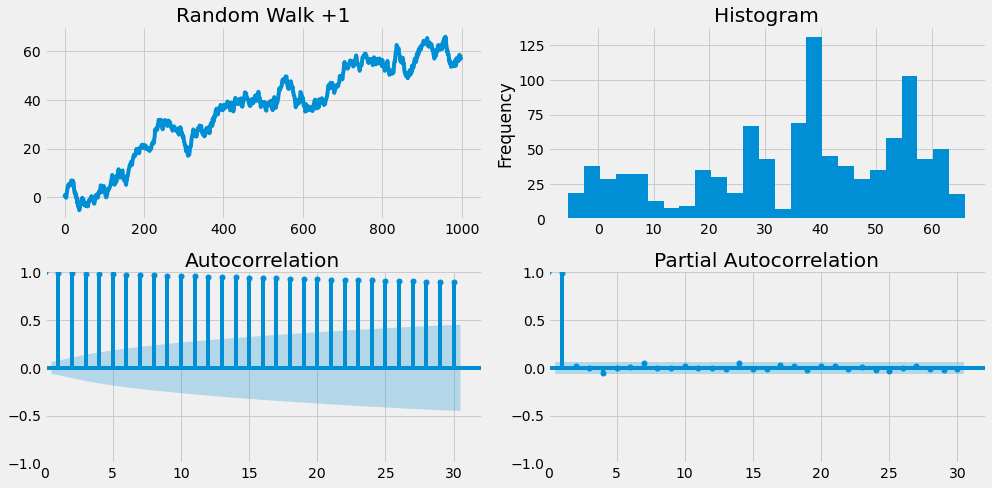

In [243]:
_ = sdt_sim(AR=[1],title='Random Walk +1')

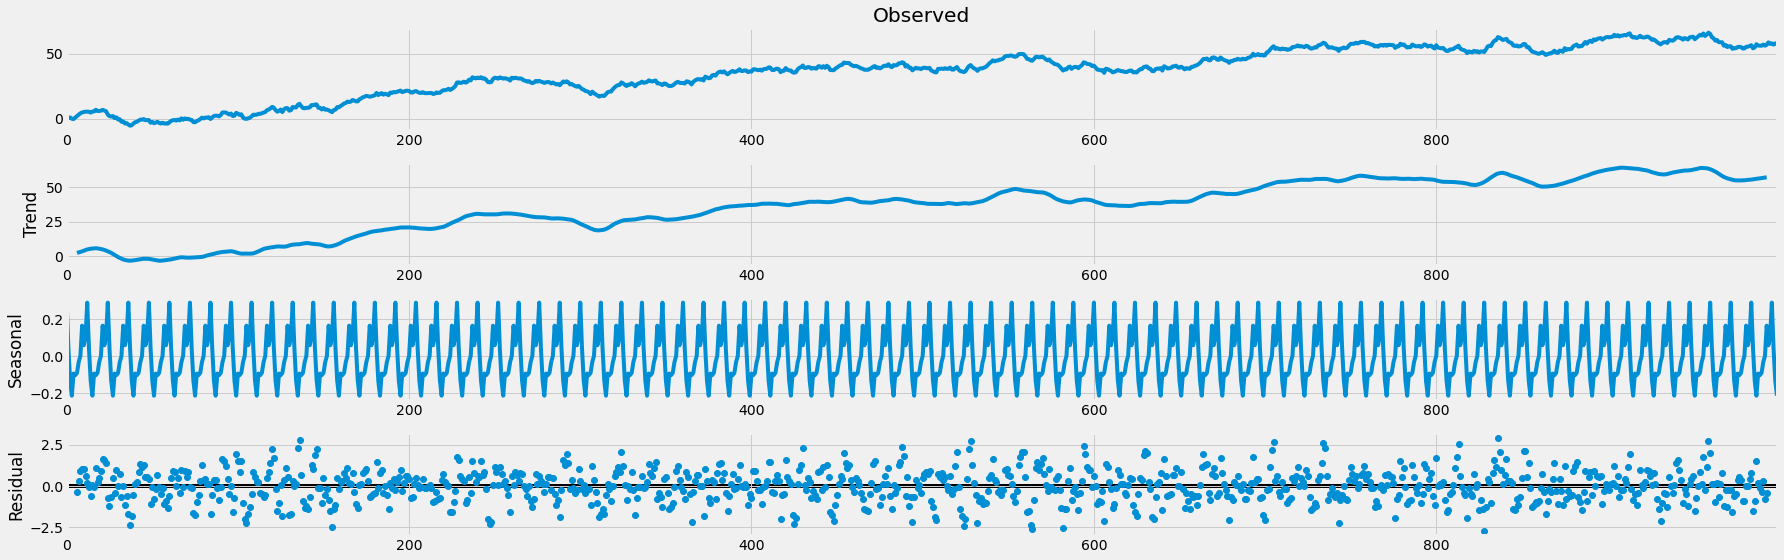

In [234]:
# Descomposición de Random Walk.... qué significa esto?
decomposition = sm.tsa.seasonal_decompose(_,period =12, model = 'additive') 
figure = decomposition.plot()
plt.show()

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


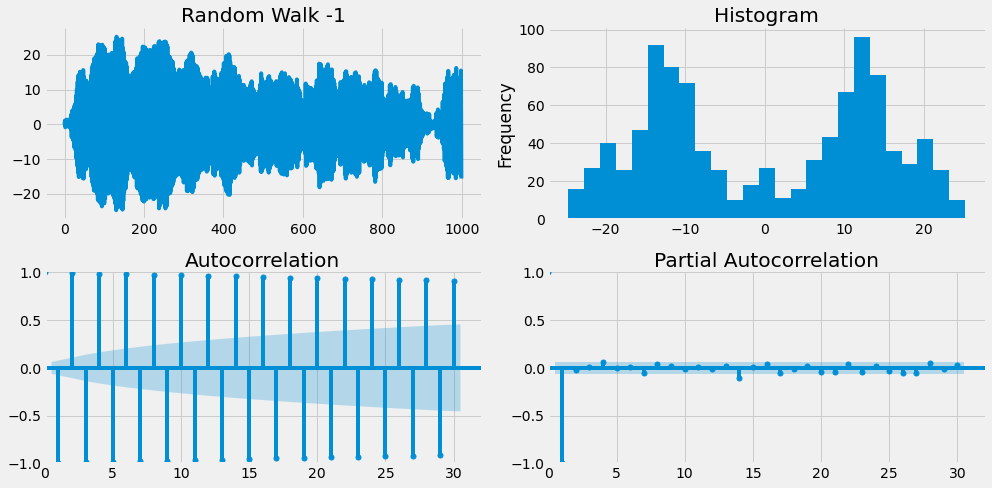

In [235]:
_ = sdt_sim(AR=[-1],title='Random Walk -1')

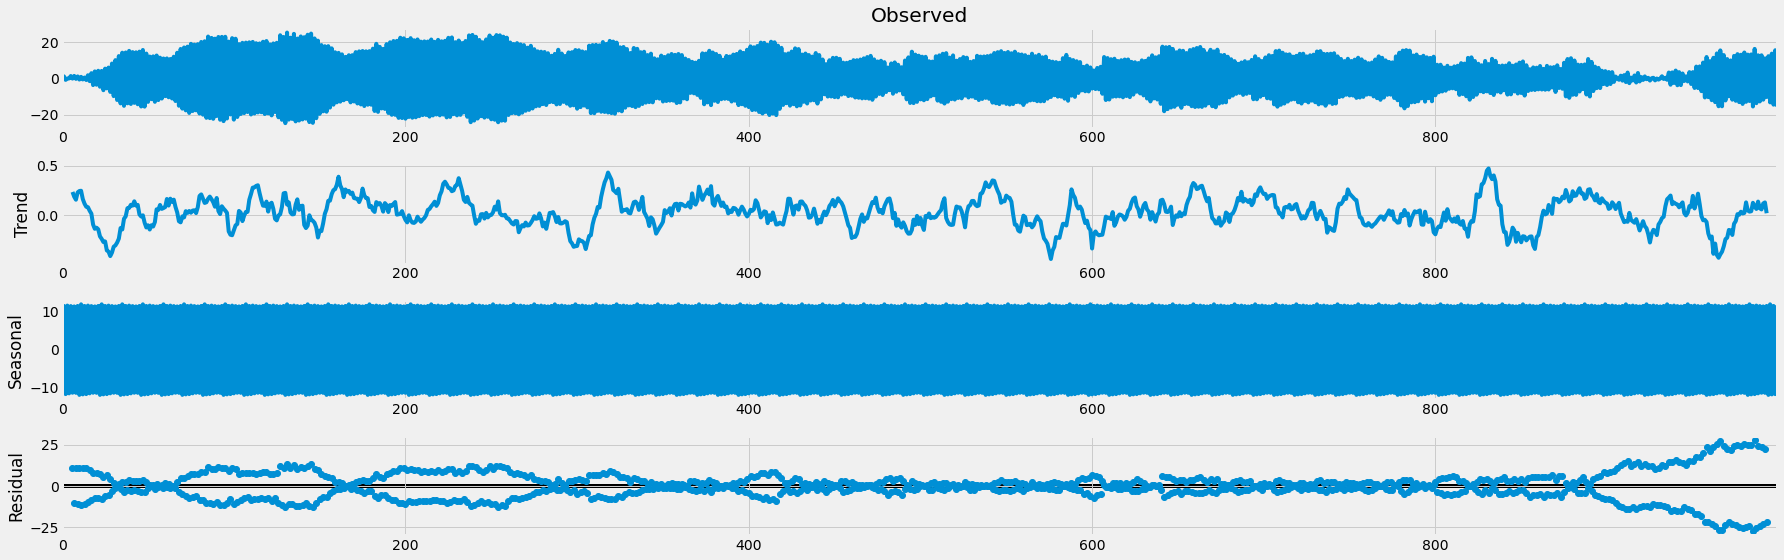

In [236]:
# Descomposición de Random Walk.... qué significa esto?
decomposition = sm.tsa.seasonal_decompose(_,period =12, model = 'additive') 
figure = decomposition.plot()
plt.show()

### AR(p)

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


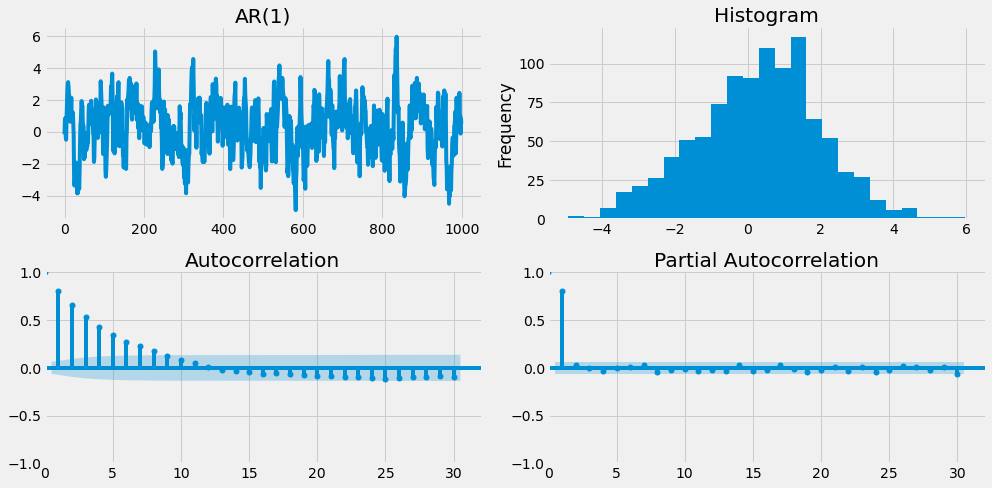

In [203]:
# AR(1)
_ = sdt_sim(AR = [.8],title='AR(1)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


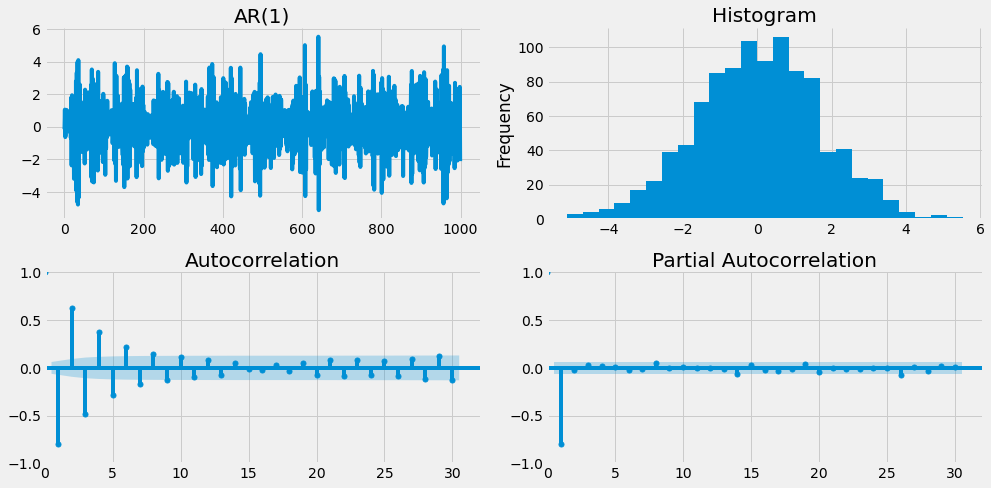

In [244]:
# AR(1)
_ = sdt_sim(AR = [-.8],title='AR(1)')

In [248]:
len(_)

1000

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


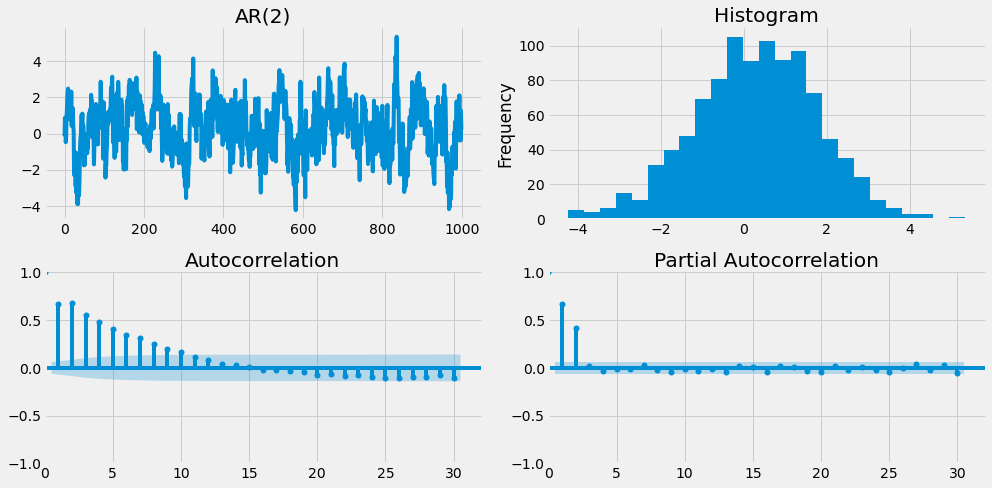

In [220]:
# AR(2)
_ = sdt_sim(AR = [.4,0.4],title='AR(2)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


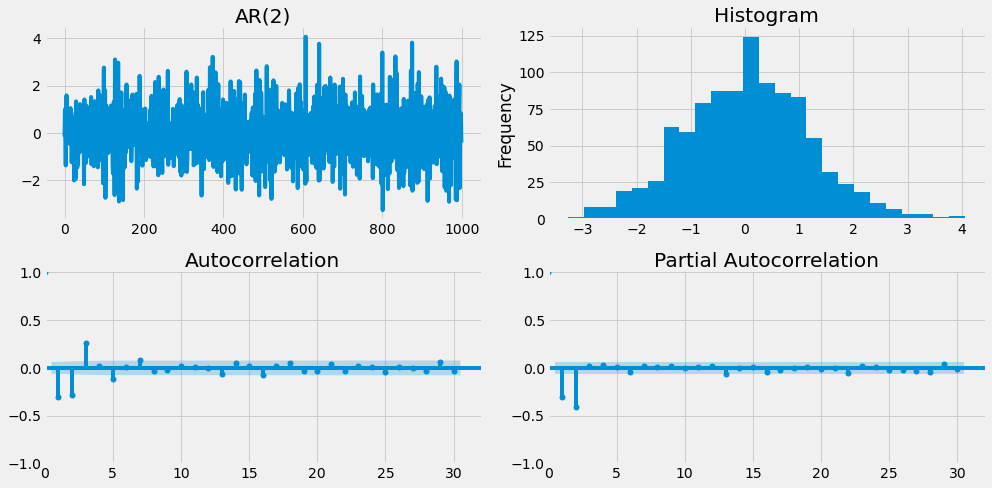

In [221]:
# AR(2)
_ = sdt_sim(AR = [-.4,-0.4],title='AR(2)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


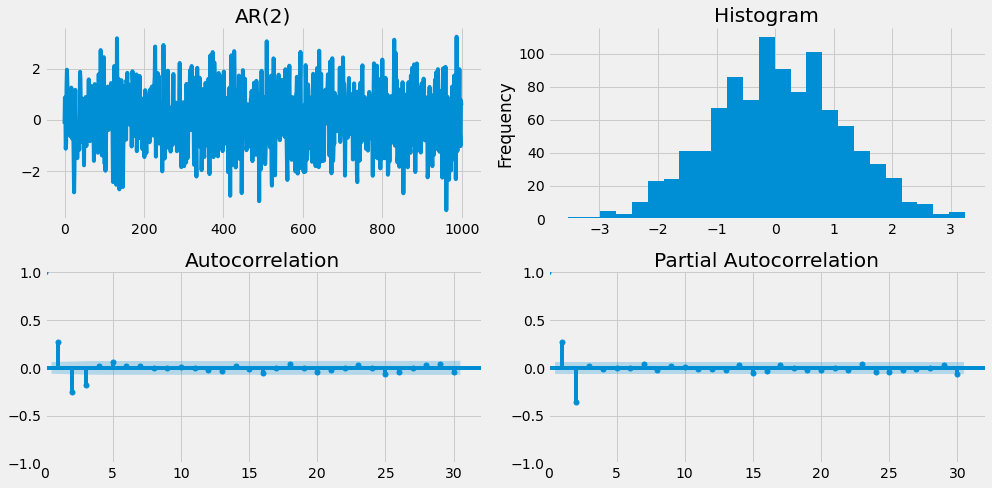

In [222]:
# AR(2)
_ = sdt_sim(AR = [.4,-0.4],title='AR(2)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


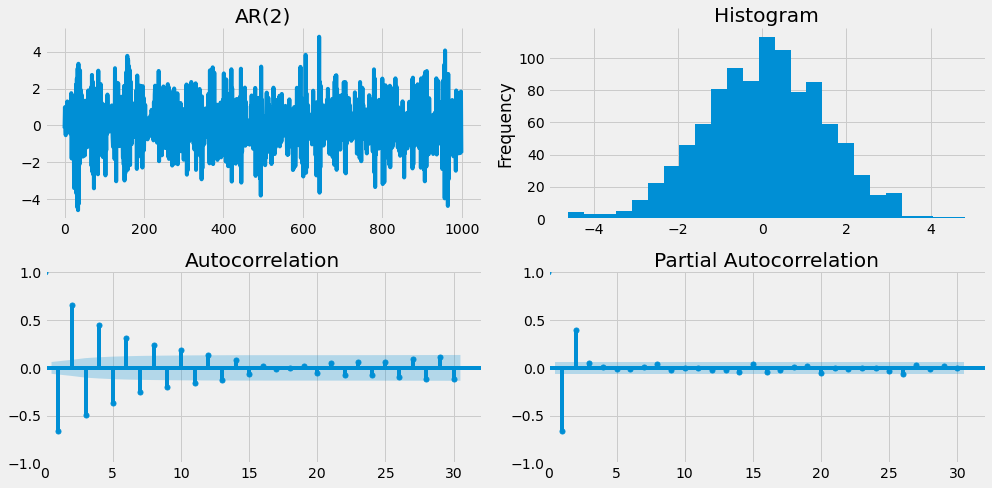

In [223]:
# AR(2)
_ = sdt_sim(AR = [-.4,.4],title='AR(2)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


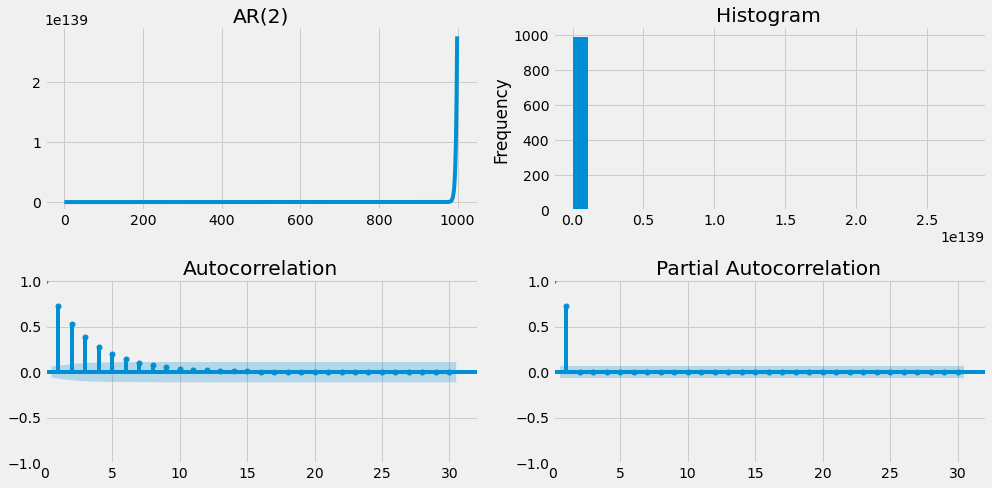

In [213]:
# CASOS EXPLOSIVOS
# AR(2): vemos que la serie no es estacionaria (la suma de los coeficiente > 1)
_ = sdt_sim(AR = [.8,0.8],title='AR(2)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


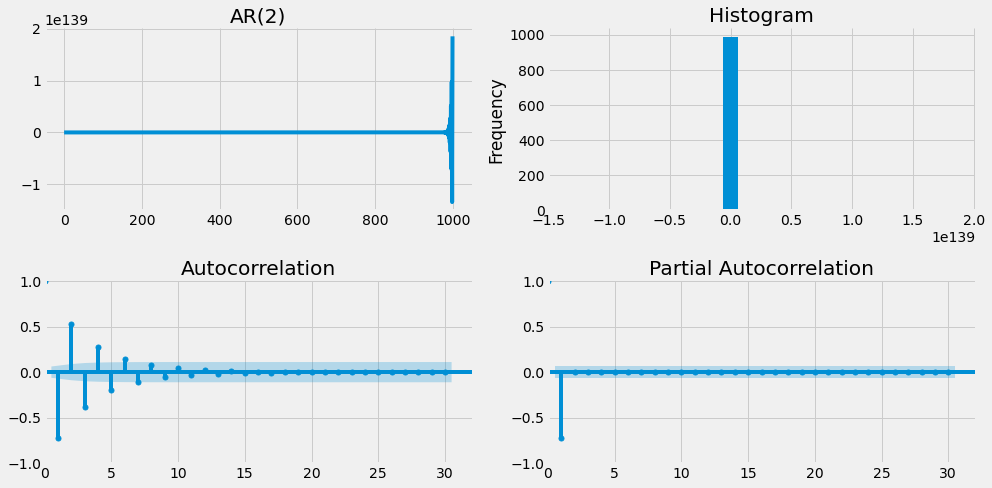

In [214]:
# AR(2): vemos que la serie no es estacionaria (la suma en módulo de los coeficiente > 1 .
# Como antes, la explosividad negativa se da en el segundo momento (la varianza), mientras que en el caso positivo lo explosivo es la media.
_ = sdt_sim(AR = [-.8,0.8],title='AR(2)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


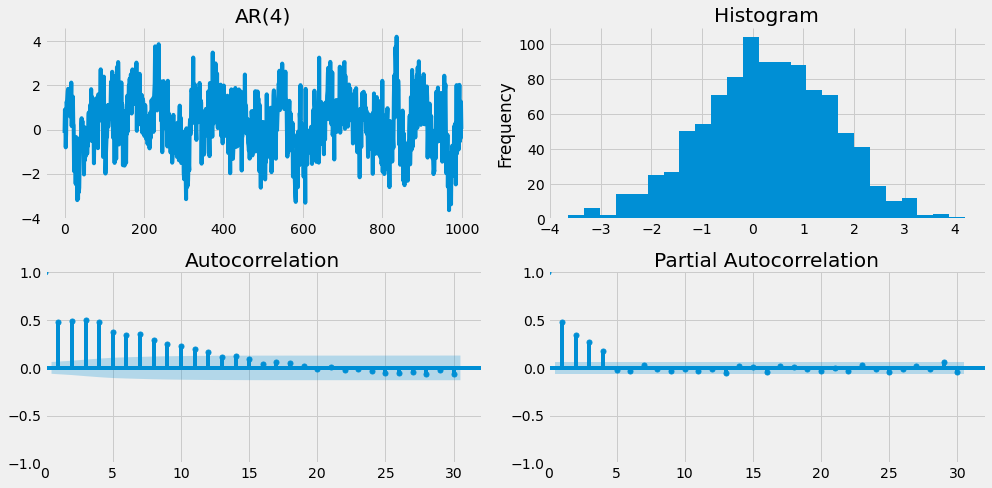

In [224]:
# AR(4) 
_ = sdt_sim(AR = [.2,0.2,0.2,0.2],title='AR(4)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


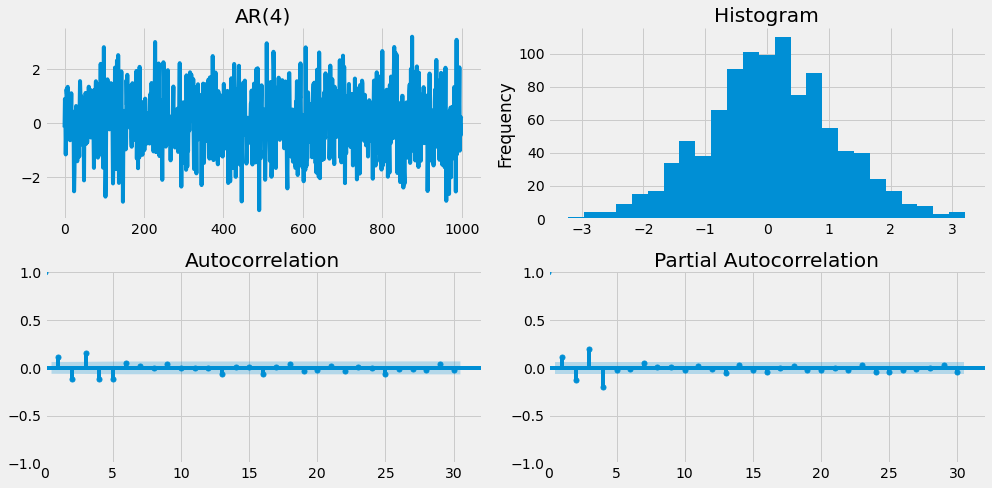

In [225]:
# AR(4) 
_ = sdt_sim(AR = [.2,-.2,.2,-.2],title='AR(4)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


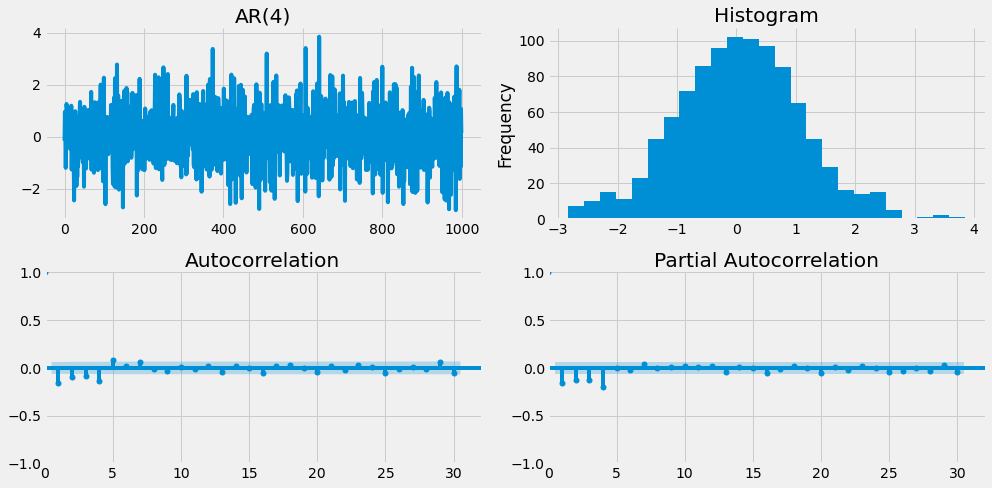

In [226]:
# AR(4) 
_ = sdt_sim(AR = [-.2,-.2,-.2,-.2],title='AR(4)')

### MA(q)

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


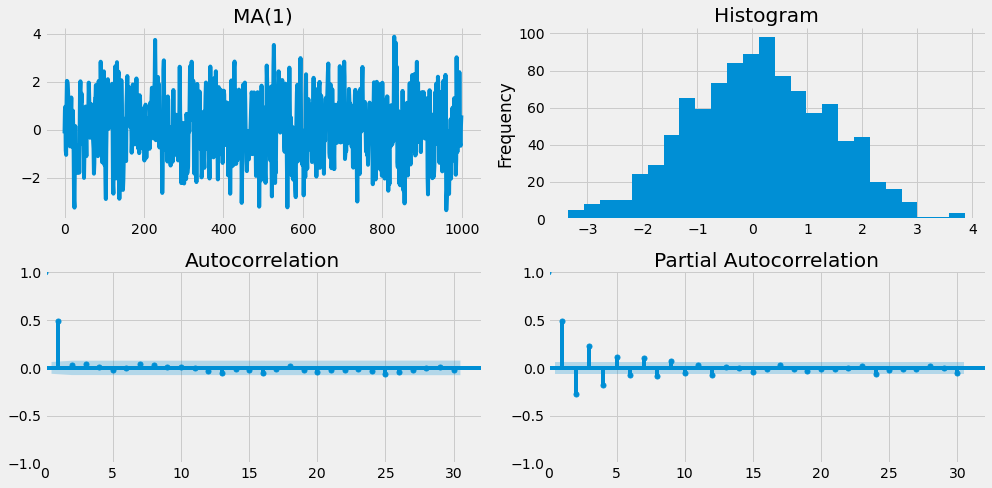

In [217]:
# MA(1)
# Vemos que estamos en espejo con los procesos AR(p). La dinámica de los correlogramas es la misma que veríamos en un proceso AR(1) (con coeficiente negativo).
_ = sdt_sim(MA = [0.8],title='MA(1)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


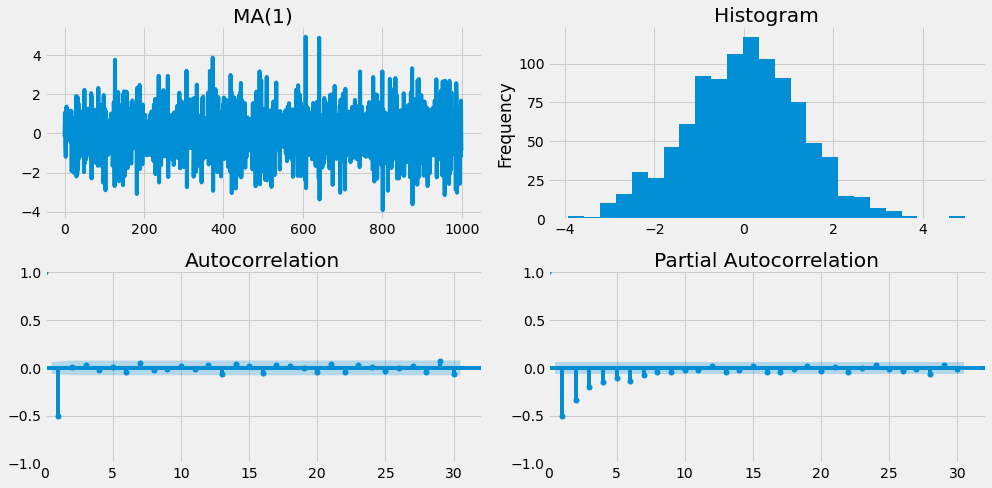

In [218]:
# MA(1)
_ = sdt_sim(MA = [-0.8],title='MA(1)')

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


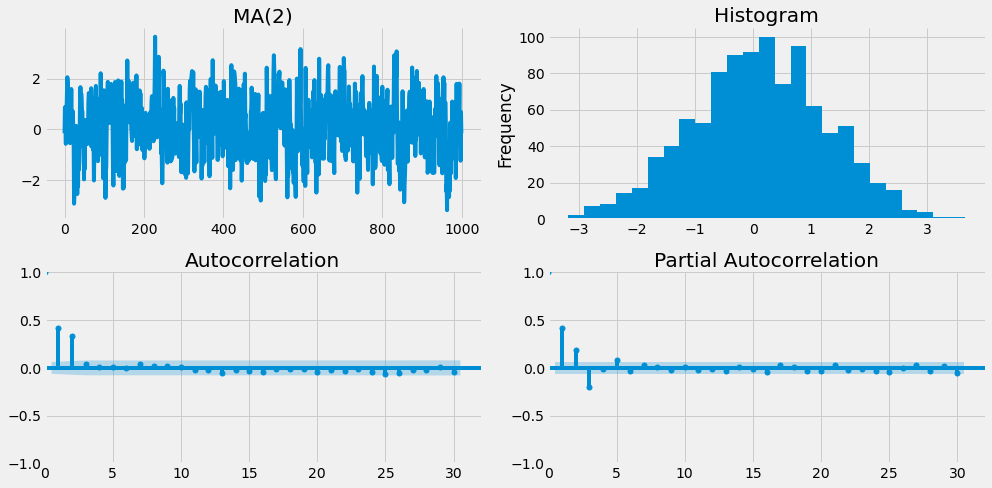

In [219]:
# MA(2)
_ = sdt_sim(MA = [.4,.4],title='MA(2)')

In [ ]:
aa

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


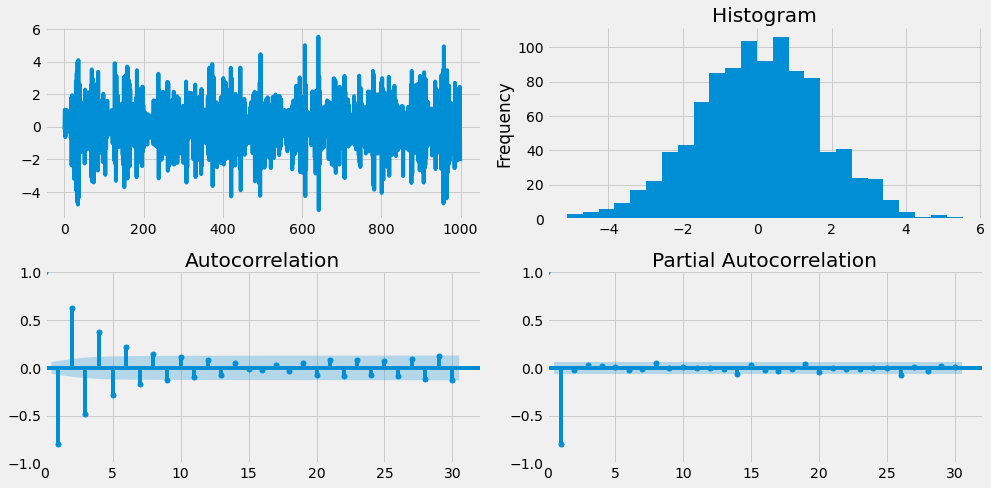

In [183]:
# AR(1)
_ = sdt_sim(AR = [-.8])

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


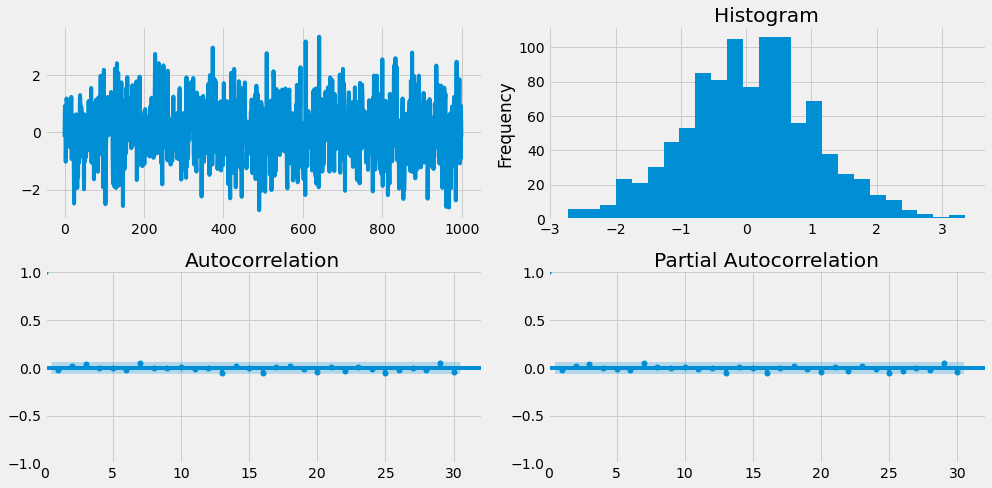

In [181]:
# No todos los procesos son modelizables:
_ = sdt_sim(AR = [-.8,0.8],MA=[0.8,-0.8])

C:\Users\juani\anaconda3\envs\series_de_tiempo\lib\site-packages\statsmodels\graphics\tsaplots.py:353: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  FutureWarning,


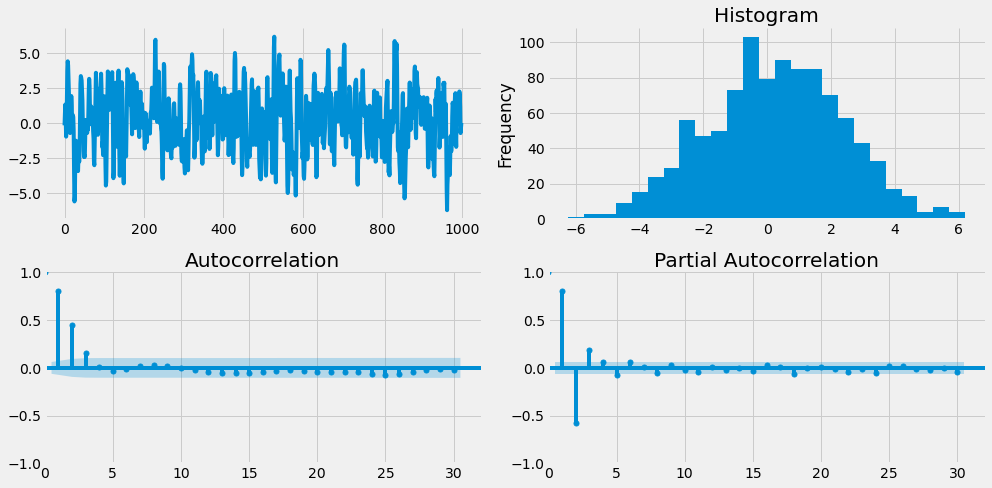

In [143]:
# import statsmodels.api as sm
# import numpy as np
np.random.seed(113)
arparams = np.array([.75, -.25])
maparams = np.array([.65, .35])
ar = np.r_[1, -arparams] # add zero-lag and negate
ma = np.r_[1, maparams] # add zero-lag
arma_process = sm.tsa.ArmaProcess(ar, ma)
y = arma_process.generate_sample(1000)
tsplot(pd.Series(y));

In [144]:
model = sm.tsa.ARIMA(endog=y, order=(2, 0, 2),trend='n')
res = model.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1418.917
Date:                Wed, 19 Apr 2023   AIC                           2847.835
Time:                        10:16:10   BIC                           2872.374
Sample:                             0   HQIC                          2857.161
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7605      0.083      9.207      0.000       0.599       0.922
ar.L2         -0.2262      0.064     -3.507      0.000      -0.353      -0.100
ma.L1          0.6235      0.080      7.784      0.0

In [145]:
arma_process.isstationary

True

In [146]:
arma_process.isinvertible

True

In [147]:
arma_process.arroots

array([1.5-1.32287566j, 1.5+1.32287566j])

In [152]:
dates = pd.date_range("1980-1-1", freq="M", periods=1000)
y = pd.Series(y, index=dates)
arma_mod = sm.tsa.ARIMA(endog=y, order=(2, 0, 2),trend='n')
arma_res = arma_mod.fit()

In [153]:
print(arma_res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1418.917
Date:                Wed, 19 Apr 2023   AIC                           2847.835
Time:                        10:23:31   BIC                           2872.374
Sample:                    01-31-1980   HQIC                          2857.161
                         - 04-30-2063                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7605      0.083      9.207      0.000       0.599       0.922
ar.L2         -0.2262      0.064     -3.507      0.000      -0.353      -0.100
ma.L1          0.6235      0.080      7.784      0.0

(<AxesSubplot:>,
 <AxesSubplot:title={'center':'Autocorrelation'}>,
 <AxesSubplot:title={'center':'Partial Autocorrelation'}>)

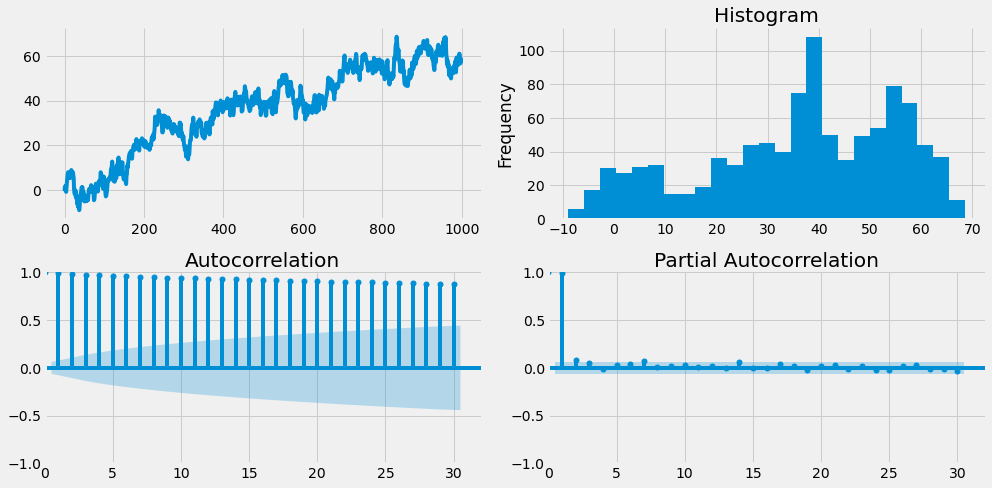

In [260]:
tsplot(pd.Series(_))

<!-- TODO:
* lag plots
* moar explanations? -->

<!-- <a id="section-five"></a>
# Causality

MOAR: Granger causality test is used to determine if one time series will be useful to forecast another. It is based on the idea that if X causes Y, then the forecast of Y based on previous values of Y AND the previous values of X should outperform the forecast of Y based on previous values of Y alone.
So, Granger causality test should not be used to test if a lag of Y causes Y. Instead, it is generally used on exogenous (not Y lag) variables only. It is implemented in the statsmodel package.
It accepts a 2D array with 2 columns as the main argument. The values are in the first column and the predictor (X) is in the second column. The Null hypothesis is that the series in the second column, does not Granger cause the series in the first. If the P-Values are less than a significance level (0.05) then we reject the null hypothesis and conclude that the said lag of X is indeed useful. The second argument maxlag says till how many lags of Y should be included in the test.a -->